# 04 · 채점표(앙상블) 재료 기록 — 인코더 토너먼트 (P8~P15)

> ⚠️ **이 노트북의 P8~P15 단일 모델은 메인 비교에서 제외된 "채점표 재료"다.** 여기서 고른 4개 리랭커를
> RRF로 합쳐 **채점표(정답 기준)**를 만든다. 메인 비교(베이스라인 vs P7)는 노트북 00 참조.

**통제 실험**: P7 레시피(aux 3피처 + PRMU 가중 pairwise, margin 0.3, 학습쌍·후보 pool 고정)를 완전히 고정하고
**인코더만** 교체한다 → 성능 차이가 인코더에서 오는지 방법론에서 오는지 판정. (`scripts/encoder_tournament.py`)

In [1]:
import sys, json, warnings
from pathlib import Path
import pandas as pd
warnings.filterwarnings("ignore")

# repo 루트 자동 탐색 (results/ 가 있는 곳) — 노트북을 어디서 열든 동작
ROOT = Path.cwd()
while not (ROOT / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))            # src.* import 가능
sys.path.insert(0, str(ROOT / "scripts"))  # 스크립트 모듈 import 가능
print("repo root:", ROOT)

repo root: C:\Users\wodlf\OneDrive\Desktop\kp20k-keyphrase-extraction


In [2]:
# 로스터 (source of truth: scripts/encoder_tournament.py 의 ROSTER dict)
roster = pd.DataFrame([
    ("P7","SciBERT","110M","CLS","과학 어휘 (기준)"),
    ("P8","SPECTER2","110M","CLS","과학 인용 신호"),
    ("P9","DeBERTa-v3","184M","CLS","무특화 — bf16 발산 실패 ✗"),
    ("P10","gte-reranker-ModernBERT","149M","CLS","리랭킹 특화(2026)"),
    ("P11","Qwen3-Reranker-0.6B","596M","last","LLM 디코더 혈통"),
    ("P12","EmbeddingGemma-300m","303M","mean","Gemma 임베딩"),
    ("P14","scideberta-cs","~180M","CLS","CS 도메인 — bf16 실패 ✗"),
    ("P15","cs_roberta","125M","CLS","CS 도메인 RoBERTa"),
], columns=["run","encoder","size","pooling","특화 축"])
roster

,run,encoder,size,pooling,특화 축
0,P7,SciBERT,110M,CLS,과학 어휘 (기준)
1,P8,SPECTER2,110M,CLS,과학 인용 신호
2,P9,DeBERTa-v3,184M,CLS,무특화 — bf16 발산 실패 ✗
3,P10,gte-reranker-ModernBERT,149M,CLS,리랭킹 특화(2026)
4,P11,Qwen3-Reranker-0.6B,596M,last,LLM 디코더 혈통
5,P12,EmbeddingGemma-300m,303M,mean,Gemma 임베딩
6,P14,scideberta-cs,~180M,CLS,CS 도메인 — bf16 실패 ✗
7,P15,cs_roberta,125M,CLS,CS 도메인 RoBERTa


### 인코더별 F1@5 — 학습 성공한 6종

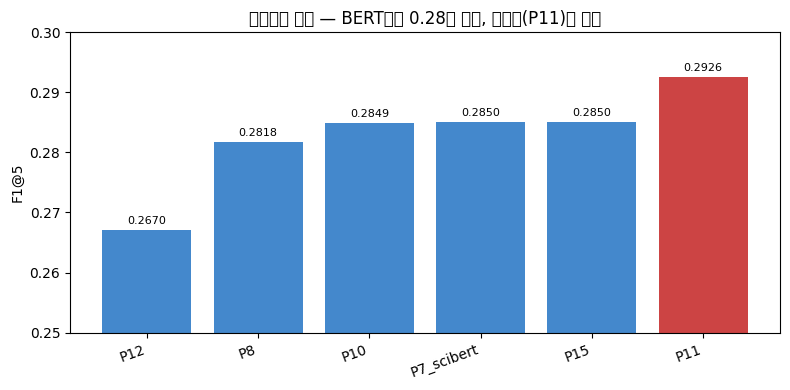

In [3]:
import matplotlib.pyplot as plt
grand = pd.read_csv(ROOT / "results/metrics/grand_comparison_all_models.csv")
enc = ["P7_scibert_hybrid_full","P8_full","P10_full","P11_full","P12_full","P15_full"]
d = grand[grand.run_id.isin(enc)].copy().sort_values("F1@5")
lab = d.run_id.str.replace("_full","",regex=False).str.replace("_hybrid","",regex=False)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(lab, d["F1@5"], color=["#c44" if v>=0.29 else "#48c" for v in d["F1@5"]])
ax.set_ylim(0.25, 0.30); ax.set_ylabel("F1@5")
ax.set_title("인코더만 교체 — BERT급은 0.28대 수렴, 디코더(P11)만 앞섬")
for i,v in enumerate(d["F1@5"]): ax.text(i, v+0.001, f"{v:.4f}", ha="center", fontsize=8)
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

**판정**: BERT급 4종(P7/P8/P10/P15)이 0.2818~0.2850으로 폭 0.0032 — **인코더 불감**. 성능은 방법론 기여.
크기 4배 디코더(P11)만 +0.0076로 유의미. 크기 3배 Gemma(P12)는 오히려 낮음 → 크기보다 **사전학습 목적**이 관건.
DeBERTa 계열(P9/P14)은 bf16 수치 불안정으로 둘 다 탈락.

### 앙상블 = 채점표 (정답 기준)

이 인코더들의 RRF 합의(P8/P10/P11/P12)는 **gold-F1을 두고 겨루는 참가 모델이 아니라,
다른 모델의 랭킹을 채점하는 채점표**다. 팀 원 요청도 "LLM으로 생성한 keyphrase 랭킹 채점표 도입"이었다.

In [4]:
# 채점표가 어떻게 구성됐나 (검증 1,000편에서 안정적 합의 조합 탐색)
es = json.load(open(ROOT / "results/metrics/ensemble_selection.json", encoding="utf-8"))
print("채점표 필수 멤버(사용자 지정):", es.get("required_member"))
print("탐색 최적 조합:", es.get("best"), " (채점표는 P7 미포함 구성 P8/P10/P11/P12 사용 — 순환 방지)")
print("\ndev 상위 조합 (합의 안정성):")
for r in es["dev_results"][:4]:
    print(f'  {"+".join(r["members"]):24s} F1@5={r["F1@5"]:.4f}')

채점표 필수 멤버(사용자 지정): P12
탐색 최적 조합: ['P7', 'P10', 'P11', 'P12']  (채점표는 P7 미포함 구성 P8/P10/P11/P12 사용 — 순환 방지)

dev 상위 조합 (합의 안정성):
  P7+P10+P11+P12           F1@5=0.3062
  P7+P11+P12               F1@5=0.3062
  P8+P10+P11+P12           F1@5=0.3057
  P2+P8+P11+P12            F1@5=0.3053


### 채점 결과 — 앙상블 채점표로 P7 vs 베이스라인 채점

In [5]:
# 앙상블 랭킹을 정답으로 둔 채점 결과 (노트북 05 산출)
comp = pd.read_csv(ROOT / "results/metrics/ensemble_reference_comparison_summary.csv")
comp

,metric,mean_hybrid_P7,mean_keybart_baseline,win_rate_P7,win_rate_keybart,wilcoxon_stat,p_value
0,nDCG@10,0.897826,0.784173,0.85165,0.14835,16340959.0,0.0
1,RBO@10,0.451763,0.325453,0.85060,0.14930,14620044.5,0.0


### 결론

- 앙상블은 **채점표(정답 기준)** — 이 기준으로 채점하면 **P7이 문서 85%에서 KeyBART 베이스라인을
  압도**(nDCG@10 0.898 vs 0.784, Wilcoxon p≈0). P7이 채점표를 가장 잘 재현하는 단일 모델이다.
- 채점 대상 단일 모델의 gold-F1 최고는 **P11(0.2926)**. 앙상블 자체 F1 수치(P16 0.3011 등)는
  `grand_comparison`에 데이터로만 남고, 경쟁 순위로는 다루지 않는다.
- Gemma(P12)는 단독 F1 최하지만 오답 패턴이 달라 채점표 합의에 기여 — **다양성 > 단독 성능**.

전 과정 해석: [`../docs/ENCODER_TOURNAMENT_STATUS.md`](../docs/ENCODER_TOURNAMENT_STATUS.md),
[`../docs/ENSEMBLE_REFERENCE_COMPARISON.md`](../docs/ENSEMBLE_REFERENCE_COMPARISON.md).